__Assignment 4__  
__Name: Bryan Lim Li Cheng__  
__Student ID: 2301214__  

# CSD3185/CSD3186: Assignment 4

## Topics Covered:  
- Support Vector Machines (SVM)
- Logistic Regression
- Decision Trees

## Python and Dependency Versions  
To ensure reproducibility and compatibility, please check that you have the following Python and dependency versions installed:

- Python >= 3.12
- pandas == 3.0.1
- numpy == 2.4.2
- matplotlib == 3.10.8
- scikit-learn == 1.8.0

## Assignment Overview: Machine Learning Model Comparison

In this assignment, you will apply **Support Vector Machines (SVM)** alongside previously learned machine learning models—**Logistic Regression and Decision Tree**—to perform a comparative analysis. The goal is to evaluate and compare the performance of these models on a given dataset using various evaluation metrics. Through this process, you will gain a deeper understanding of how different classification algorithms perform under different conditions and learn to fine-tune models for optimal results.


## Dataset:

The Heart Disease dataset is a widely used dataset from the UCI Machine Learning Repository. It contains medical data used to predict the presence of heart disease in patients. The dataset consists of multiple patient attributes, including demographic, clinical, and laboratory test results.

#### Dataset Details  
- **Number of Features:** 13  
- **Target Variable:** `target` (1 = presence of heart disease, 0 = absence of heart disease)  
- **Type:** Classification  

#### Features  
| Feature | Description |
|---------|------------|
| `age` | Age of the patient (years) |
| `sex` | Sex of the patient (1 = male, 0 = female) |
| `cp` | Chest pain type (0-3, different types of angina and pain) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dL) |
| `fbs` | Fasting blood sugar > 120 mg/dL (1 = true, 0 = false) |
| `restecg` | Resting electrocardiographic results (0-2) |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1 = yes, 0 = no) |
| `oldpeak` | ST depression induced by exercise relative to rest |
| `slope` | Slope of the peak exercise ST segment (0-2) |
| `ca` | Number of major vessels colored by fluoroscopy (0-3) |
| `thal` | Thalassemia type (1 = normal, 2 = fixed defect, 3 = reversible defect) |
| `target` | Presence of heart disease (1 = disease, 0 = no disease) |

## Deliverables

Your submission for this assignment should be only __ONE__ file - this particular completed notebook file. 

Also, *RENAME* your file like this: __\<coursecode\>\_<assignment#>\_<your_full_name>.ipynb__  
Eg. CS3185_A4_John_Doe.ipynb  

To complete this assignment, you should follow instructions in below section Tasks.

## IMPORTANT! READ THIS BEFORE STARTING...
- DO NOT delete existing cells, but you can add more cells anywhere in the notebook as necessary.
- DO NOT modify or comment out the content of the existing cells unless otherwise stated (e.g., for code implementation). However, DO NOT change the variable names that are already defined in the existing cells.
- Follow the file naming convention for the notebook file as spelled out above strictly.

Please adhere strictly to the instructions as stated above as failure to do so might result in deduction of marks by the autograder.

Your assignment begins after the line below!! Complete all the tasks as specified.

---
---

## 1. Data Loading & Cleaning

Load some basic libraries upfront. You may add any other libraries you deem necessary below or later on where appropriate.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

**Task 1:**

- Load the dataset and check for **duplicates**.

- Check shape of the dataset.

- Check for duplicates.

- Remove duplicates.

In [28]:
# Load data
df = pd.read_csv("heart.csv")

# Check shape
data_shape = df.shape
data_shape

(303, 14)

In [29]:
# Check for duplicates
has_duplicates = df.duplicated().any()

# Drop duplicates
df = df.drop_duplicates()
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 2. Exploratory Data Analysis (EDA)

**Task 2.1:**  

- Plot a histogram of **age** with **20 bins**.

Include appropriate titles and axis labels for the histogram.

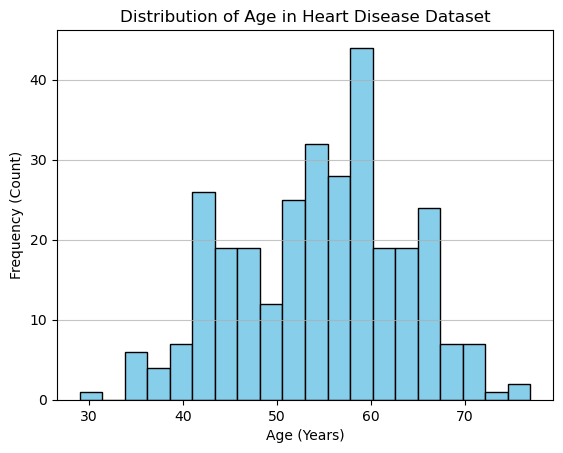

In [18]:
# Plot class distribution of target variable using matplotlib
counts, bin_edges, _ = plt.hist(df['age'], bins=20, color='skyblue', edgecolor='black')
# include title and labels
plt.title('Distribution of Age in Heart Disease Dataset')
plt.xlabel('Age (Years)')
plt.ylabel('Frequency (Count)')

# Display the plot
plt.grid(axis='y', alpha=0.75)
plt.show()

**Task 2.2:**  

- Plot **class distribution** of the target variable (**target**).

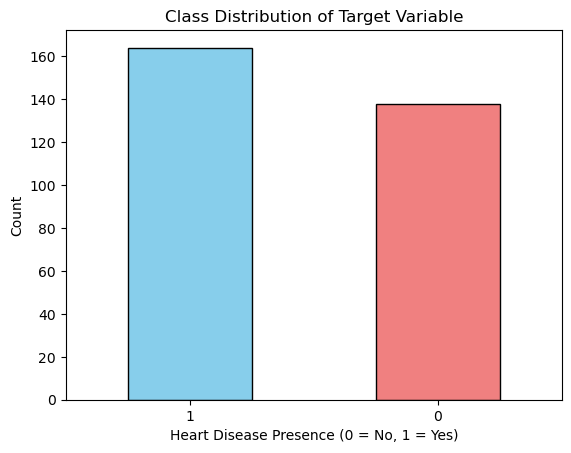

In [22]:
# Plot class distribution of target variable
ax_count = df['target'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'], edgecolor='black')
# Set title
ax_count.set_title('Class Distribution of Target Variable')
ax_count.set_xlabel('Heart Disease Presence (0 = No, 1 = Yes)')
ax_count.set_ylabel('Count')
# Rotate x-axis labels so they are readable
plt.xticks(rotation=0)
plt.show()

**Task 2.3:**  

- Visualize **correlations** between features and the target using a **heatmap**.

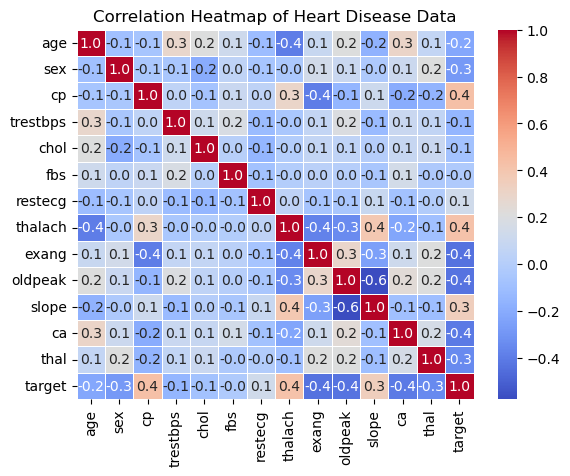

In [24]:
# Compute the correlation matrix of your dataframe
corr_matrix = df.corr()

# Correlation heatmap
# Ensure each cell displays the correlation value (annot)
# The values are formatted to one decimal place (fmt)
ax = sns.heatmap(corr_matrix, annot=True, fmt='.1f', cmap='coolwarm', linewidths=0.5)

# Set title for heatmap
ax.set_title('Correlation Heatmap of Heart Disease Data')

plt.show()

**Task 2.4:**  

- Identify **outliers** in **Cholesterol (chol)** and **ST depression (oldpeak)** using **boxplots**.

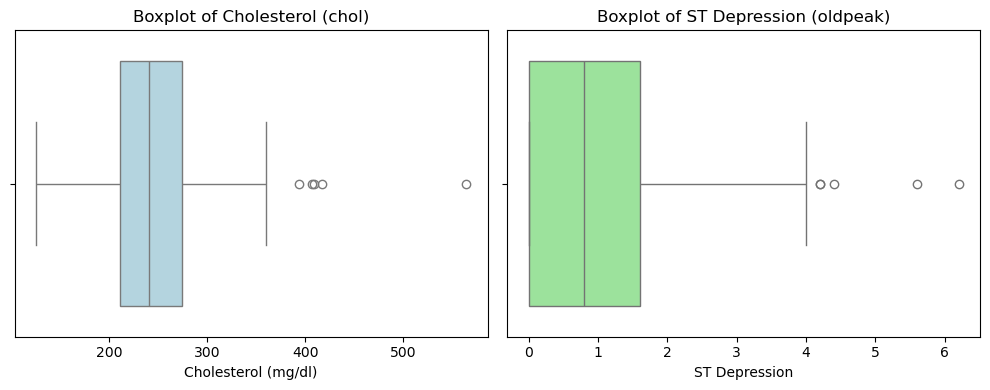

In [25]:
# Inspect outliers (boxplots) using seaborn
plt.figure(figsize=(10, 4))

# First subplot: Cholesterol
plt.subplot(1, 2, 1)
ax1 = sns.boxplot(x=df['chol'], color='lightblue')
ax1.set_title('Boxplot of Cholesterol (chol)')
ax1.set_xlabel('Cholesterol (mg/dl)')

# Second subplot: ST depression (oldpeak)
plt.subplot(1, 2, 2)
ax2 = sns.boxplot(x=df['oldpeak'], color='lightgreen')
ax2.set_title('Boxplot of ST Depression (oldpeak)')
ax2.set_xlabel('ST Depression')

# This prevents the titles and labels from overlapping
plt.tight_layout() 

# Display the plots
plt.show()

## 3. Feature Engineering

**Tasks 3:**

Create new features based on existing ones to potentially improve model performance:

- **Bin** `age` into groups: `<=45`, `45-55`, `>55`, labelled as **'young'**, **'middle'**, **'senior'**. (Hint: use pd.cut())

- **Create interaction term** `age_chol` (**age × cholesterol**).

Create new variable `df2` to store the modified dataset with new features. Use `df2` for all subsequent tasks unless otherwise specified.

In [27]:
# Create new copy for feature engineering
df2 = df.copy()

# Bin Age into Groups
df2['age_group'] = pd.cut(df2['age'], bins=[0, 45, 55, float('inf')], labels=['young', 'middle', 'senior'])

# Create Interaction Term
df2['age_chol'] = df2['age'] * df2['chol']

print(df2[['age', 'age_group', 'chol', 'age_chol']].head())

   age age_group  chol  age_chol
0   63    senior   233     14679
1   37     young   250      9250
2   41     young   204      8364
3   56    senior   236     13216
4   57    senior   354     20178


## 4. Data Preprocessing & Feature Selection

**Task 4.1:**

Separate the dataset into features (X) and target variable (y). Then, split the data into training and testing sets using an 80-20 split.

In [ ]:
from sklearn.model_selection import train_test_split

# Split Data into Features (X) and Target (y)
X = ...
y = ...

# Train-Test Split (80% Train, 20% Test)
# Use random_state = 42 for reproducibility.
# Use stratify = y to ensure the train and test sets have similar class distributions.
X_train, X_test, y_train, y_test = ...

**Task 4.2:**

Complete the following functions to handle outliers with IQR method:

- `calculate_outlier_bounds(df, column)`: This function calculates the lower and upper bounds for outliers in a specified column using the IQR method.
- `apply_outlier_bounds(df, columns, bounds)`: This function applies the calculated outlier bounds to the specified columns in the DataFrame, replacing outliers with the respective bounds.

Subsequently, apply these functions to the `chol` and `oldpeak` columns in the training set to handle outliers in the steps that follow.

In [ ]:
# Data Preprocessing: Handling Outliers with IQR Method

def calculate_outlier_bounds(df, columns):
    """
    Calculate IQR-based outlier bounds using ONLY training data to prevent data leakage.
    
    IQR (Interquartile Range) Method:
    - Q1 (25th percentile): The value below which 25% of the observations are found
    - Q3 (75th percentile): The value below which 75% of the observations are found
    - IQR = Q3 - Q1: The range of the middle 50% of the data
    - Lower bound = Q1 - 1.5 * IQR: Values below this are considered outliers
    - Upper bound = Q3 + 1.5 * IQR: Values above this are considered outliers
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The training DataFrame containing numerical columns
    columns : list
        List of column names to calculate IQR bounds for
        
    Returns:
    --------
    bounds : dict
        Dictionary with column names as keys and their corresponding lower/upper bounds
    """
    # Initialize empty dictionary to store bounds for each column
    bounds = {}
   
    
    # Calculate bounds for each specified column
    for col in columns:
        ...
        lower_bound = ...
        upper_bound = ...
        
        # Store bounds for this column in the dictionary
        bounds[col] = {
            'lower': lower_bound,
            'upper': upper_bound
        }
    
    return bounds


def apply_outlier_bounds(df, columns, bounds):
    """
    Apply pre-calculated outlier bounds to a dataset (training or test).
    
    This function ensures we apply the SAME bounds to both training and test data,
    preventing data leakage by not calculating new bounds from test data.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The DataFrame to apply outlier capping to (can be training or test set)
    columns : list
        List of column names to apply outlier capping to
    bounds : dict
        Dictionary of pre-calculated bounds from training data
        
    Returns:
    --------
    df_capped : pandas.DataFrame
        A new DataFrame with outliers capped at the specified bounds
    """
    # Create a copy to avoid modifying the original DataFrame
    df_capped = df.copy()

    # Apply capping to each specified column
    for col in columns:
        # Extract pre-calculated bounds for this column
        lower_bound = ...
        upper_bound = ...
        
        # Use np.clip to cap values at the lower and upper bounds
        # - Values below lower_bound will be set to lower_bound
        # - Values above upper_bound will be set to upper_bound
        # - Values within the range remain unchanged
        df_capped[col] = ...

    return df_capped


# STEP 1: Define columns that need outlier handling
outlier_columns = ['chol', 'oldpeak']

# STEP 2: Calculate bounds using ONLY training data
outlier_bounds = ...

# STEP 3:
# Apply the bounds to training data
X_train_capped = ...

# Apply the SAME bounds to test data (prevents data leakage)
X_test_capped = ...

# IMPORTANT: Replace original dataframes with capped versions
X_train = ...
X_test = ...

**Task 4.3:**

Follow the steps/comments below to perform one-hot encoding for categorical features:

In [ ]:


# Step 1: Identify categorical features requiring one-hot encoding
encoded_features = ['cp', 'restecg', 'slope', 'thal', 'ca', 'age_group']

# Step 2: Initialize one-hot encoder (drop first category to avoid multicollinearity)
# Set drop='first' removes one column per feature to avoid perfect multicollinearity
# Set sparse_output = False, which is equivalent to calling .toarray()
encoder = ...

# Step 3: Fit on training data and transform both train and test sets
# Create a DataFrame with proper column names for the encoded features 
# - encoder.fit_transform() learns categories from AND transforms training data
# - encoder.get_feature_names_out() provides clear column names for the encoded features 
X_train_encoded = ...

# Important: We only transform test data (not fit_transform) to prevent data leakage
X_test_encoded = ...

# Step 4: Identify remaining features (those not selected for one-hot encoding)
remaining_features = ...

# Step 5: Concatenate remaining features and one-hot encoded categorical features
X_train = ...
X_test = ...

**Task 4.4:**

Standardize the numerical features using `StandardScaler`. Ensure that you fit the scaler on the training data and then transform both the training and testing data to prevent data leakage.

In [ ]:
# Standardize Numerical Features
scaler = ...
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'age_chol']

X_train[numeric_features] = ...
X_test[numeric_features] = ...

**Task 4.5:** [No code implementation required]

### Introduction to RFE (Recursive Feature Elimination) [Codes Provided]
**Recursive Feature Elimination (RFE)** is a feature selection technique that helps identify the most important features for a machine learning model. It works by:

1. **Training a model** on all features.
2. **Ranking features** based on their importance (using model coefficients or feature importance scores).
3. **Eliminating the least important feature(s)** and repeating the process until the desired number of features is reached.

**Why use RFE?**

- Reduces overfitting by removing irrelevant features.
- Improves model interpretability.
- Enhances computational efficiency.

It is commonly used with models like **Logistic Regression**, **Decision Trees**, and **SVM** to optimize performance. In our example, we will use RFE with Logistic regression. 

The selected features are:
```python
['exang', 'cp_1', 'cp_2', 'cp_3', 'slope_1', 'thal_2', 'thal_3', 'ca_1', 'ca_2', 'ca_3']
```

In [ ]:
# Feature Selection using Recursive Feature Elimination (RFE)
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(model, n_features_to_select=10)  # Adjust based on desired number of features
X_train_selected = rfe.fit_transform(X_train, y_train)
X_test_selected = rfe.transform(X_test)  # Apply the same transformation to test set

# Print selected feature indices
selected_features = X_train.columns[rfe.support_]
print(f"Selected Features: {selected_features.tolist()}")

## 5. Model Training & Selection

**Task 5.1:**

- Train the following models on the training data with selected features with hyperparameter tuning using GridSearchCV:
  - **Logistic Regression**
  - **Support Vector Machine (SVM)**
  - **Decision Tree**

Use the pre-defined parameter grids for each model as specified in Step 1 in the code cell below.

In [ ]:
# Step 1: Initialize Models & Parameter Grids (codes provided)
models = {
    'Logistic Regression': LogisticRegression(max_iter = 1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'saga']
    },
    'Decision Tree': {
        'max_depth': [None, 5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'SVM': {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto', 0.1, 0.01]
    }
}

In [ ]:
# Complete the code below
# Step 2: Hyperparameter Tuning with Cross-validation
best_models = {}
cv_scores = {}  # Store cross-validation scores for each model

for name, model in models.items():
    print(f"\nPerforming Grid Search for {name}")

    grid_search = GridSearchCV(
        ...
        ...
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    # Fit on training data
    ...

    # Store the best estimator
    best_models[name] = ...
    # Store the best cross-validation score
    cv_scores[name] = ...

    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best cross-validation score: {cv_scores[name]:.4f}")

# Step 3: Select the best model based on CV score
best_model_name = max(cv_scores, key=cv_scores.get)  # Model with highest CV score
# Retrieve the best trained model object from best_models dictionary
best_model = ...

print(f"\nBest model based on cross-validation: {best_model_name}")

**Task 5.2:**

Evaluate the best model on the test data and report the test accuracy. Also, provide a classification report including precision, recall, and F1-score for each class.

In [ ]:
# Evaluate the Best Model on Test Data
y_pred = ...

test_accuracy = ...

print(f"\nTest Accuracy of {best_model_name}: {test_accuracy:.4f}")
print("\nClassification Report:")
# print classification report
...

<div style="display: flex; align-items: center; gap: 8px; margin: 12px 0; color: #868181;">
  <hr style="flex: 1; border: none; border-top: 1px solid #ccc;">
  <span style="font-size: 1.2em;">END ASSIGNMENT</span>
  <hr style="flex: 1; border: none; border-top: 1px solid #ccc;">
</div>
